# Stage 6 — Figures of record

Rebuilds the figures (figA, figB, figD, figE, figF) and the repository-only pipeline diagram (figC) from saved products. The graph figures read the corpus for titles; all others are product-only.

In [1]:
import os, pathlib, sys
root = pathlib.Path.cwd()
for _ in range(6):
    if (root / "scripts").is_dir() and (root / "data").is_dir(): break
    root = root.parent
else:
    raise SystemExit("repository root (containing scripts/ and data/) not found within 6 levels")
os.chdir(root); print("working directory:", os.getcwd())
assert "igraph" in {m.split("==")[0] for m in os.popen(f"{sys.executable} -m pip list --format=freeze 2>/dev/null").read().split()}, \
    f"kernel {sys.executable} lacks python-igraph: select the grb-venv kernel (see notebooks/README.md)"

working directory: /Users/salim/Desktop/Projects/Astrograph/GRB_Community_Structure


In [2]:
CORPUS = "data/raw/ads_corpus_v2_core_frozen.jsonl"  # local-only frozen corpus (ADS terms); see README
import pathlib
HAVE_CORPUS = pathlib.Path(CORPUS).exists()
print("frozen corpus present:", HAVE_CORPUS)

frozen corpus present: True


In [3]:
if HAVE_CORPUS:
    %run scripts/fig_graph_anatomy.py
else:
    print("figA/figB need the corpus for node titles; shipped PDFs are in paper/figures/")

canonical graph: 13,800 nodes, 380,361 edges


  wrote paper/figures/figA_graph_anatomy.pdf/.png
  figure B draws 13,645 of 13,800 vertices and 380,018 of 380,361 edges (155 vertices in groups below the 30-paper display threshold)


  figure B renders 80,000 of 380,018 links (21%, sampled for legibility)


  wrote paper/figures/figB_citation_graph.pdf/.png


In [4]:
%run scripts/fig_role_plane.py

wrote /Users/salim/Desktop/Projects/Astrograph/GRB_Community_Structure/paper/figures/figD_role_plane.pdf/.png  (7,562 stable-core papers)


In [5]:
%run scripts/fig_alluvial.py

wrote /Users/salim/Desktop/Projects/Astrograph/GRB_Community_Structure/paper/figures/figE_alluvial.pdf/.png


In [6]:
%run scripts/fig_infomap_nesting.py

wrote /Users/salim/Desktop/Projects/Astrograph/GRB_Community_Structure/paper/figures/figF_infomap_nesting.pdf/.png


In [7]:
%run scripts/fig_pipeline.py  # repository-only

  wrote /Users/salim/Desktop/Projects/Astrograph/GRB_Community_Structure/paper/figures/figC_pipeline.pdf/.png


## The figures, inline

figA_graph_anatomy


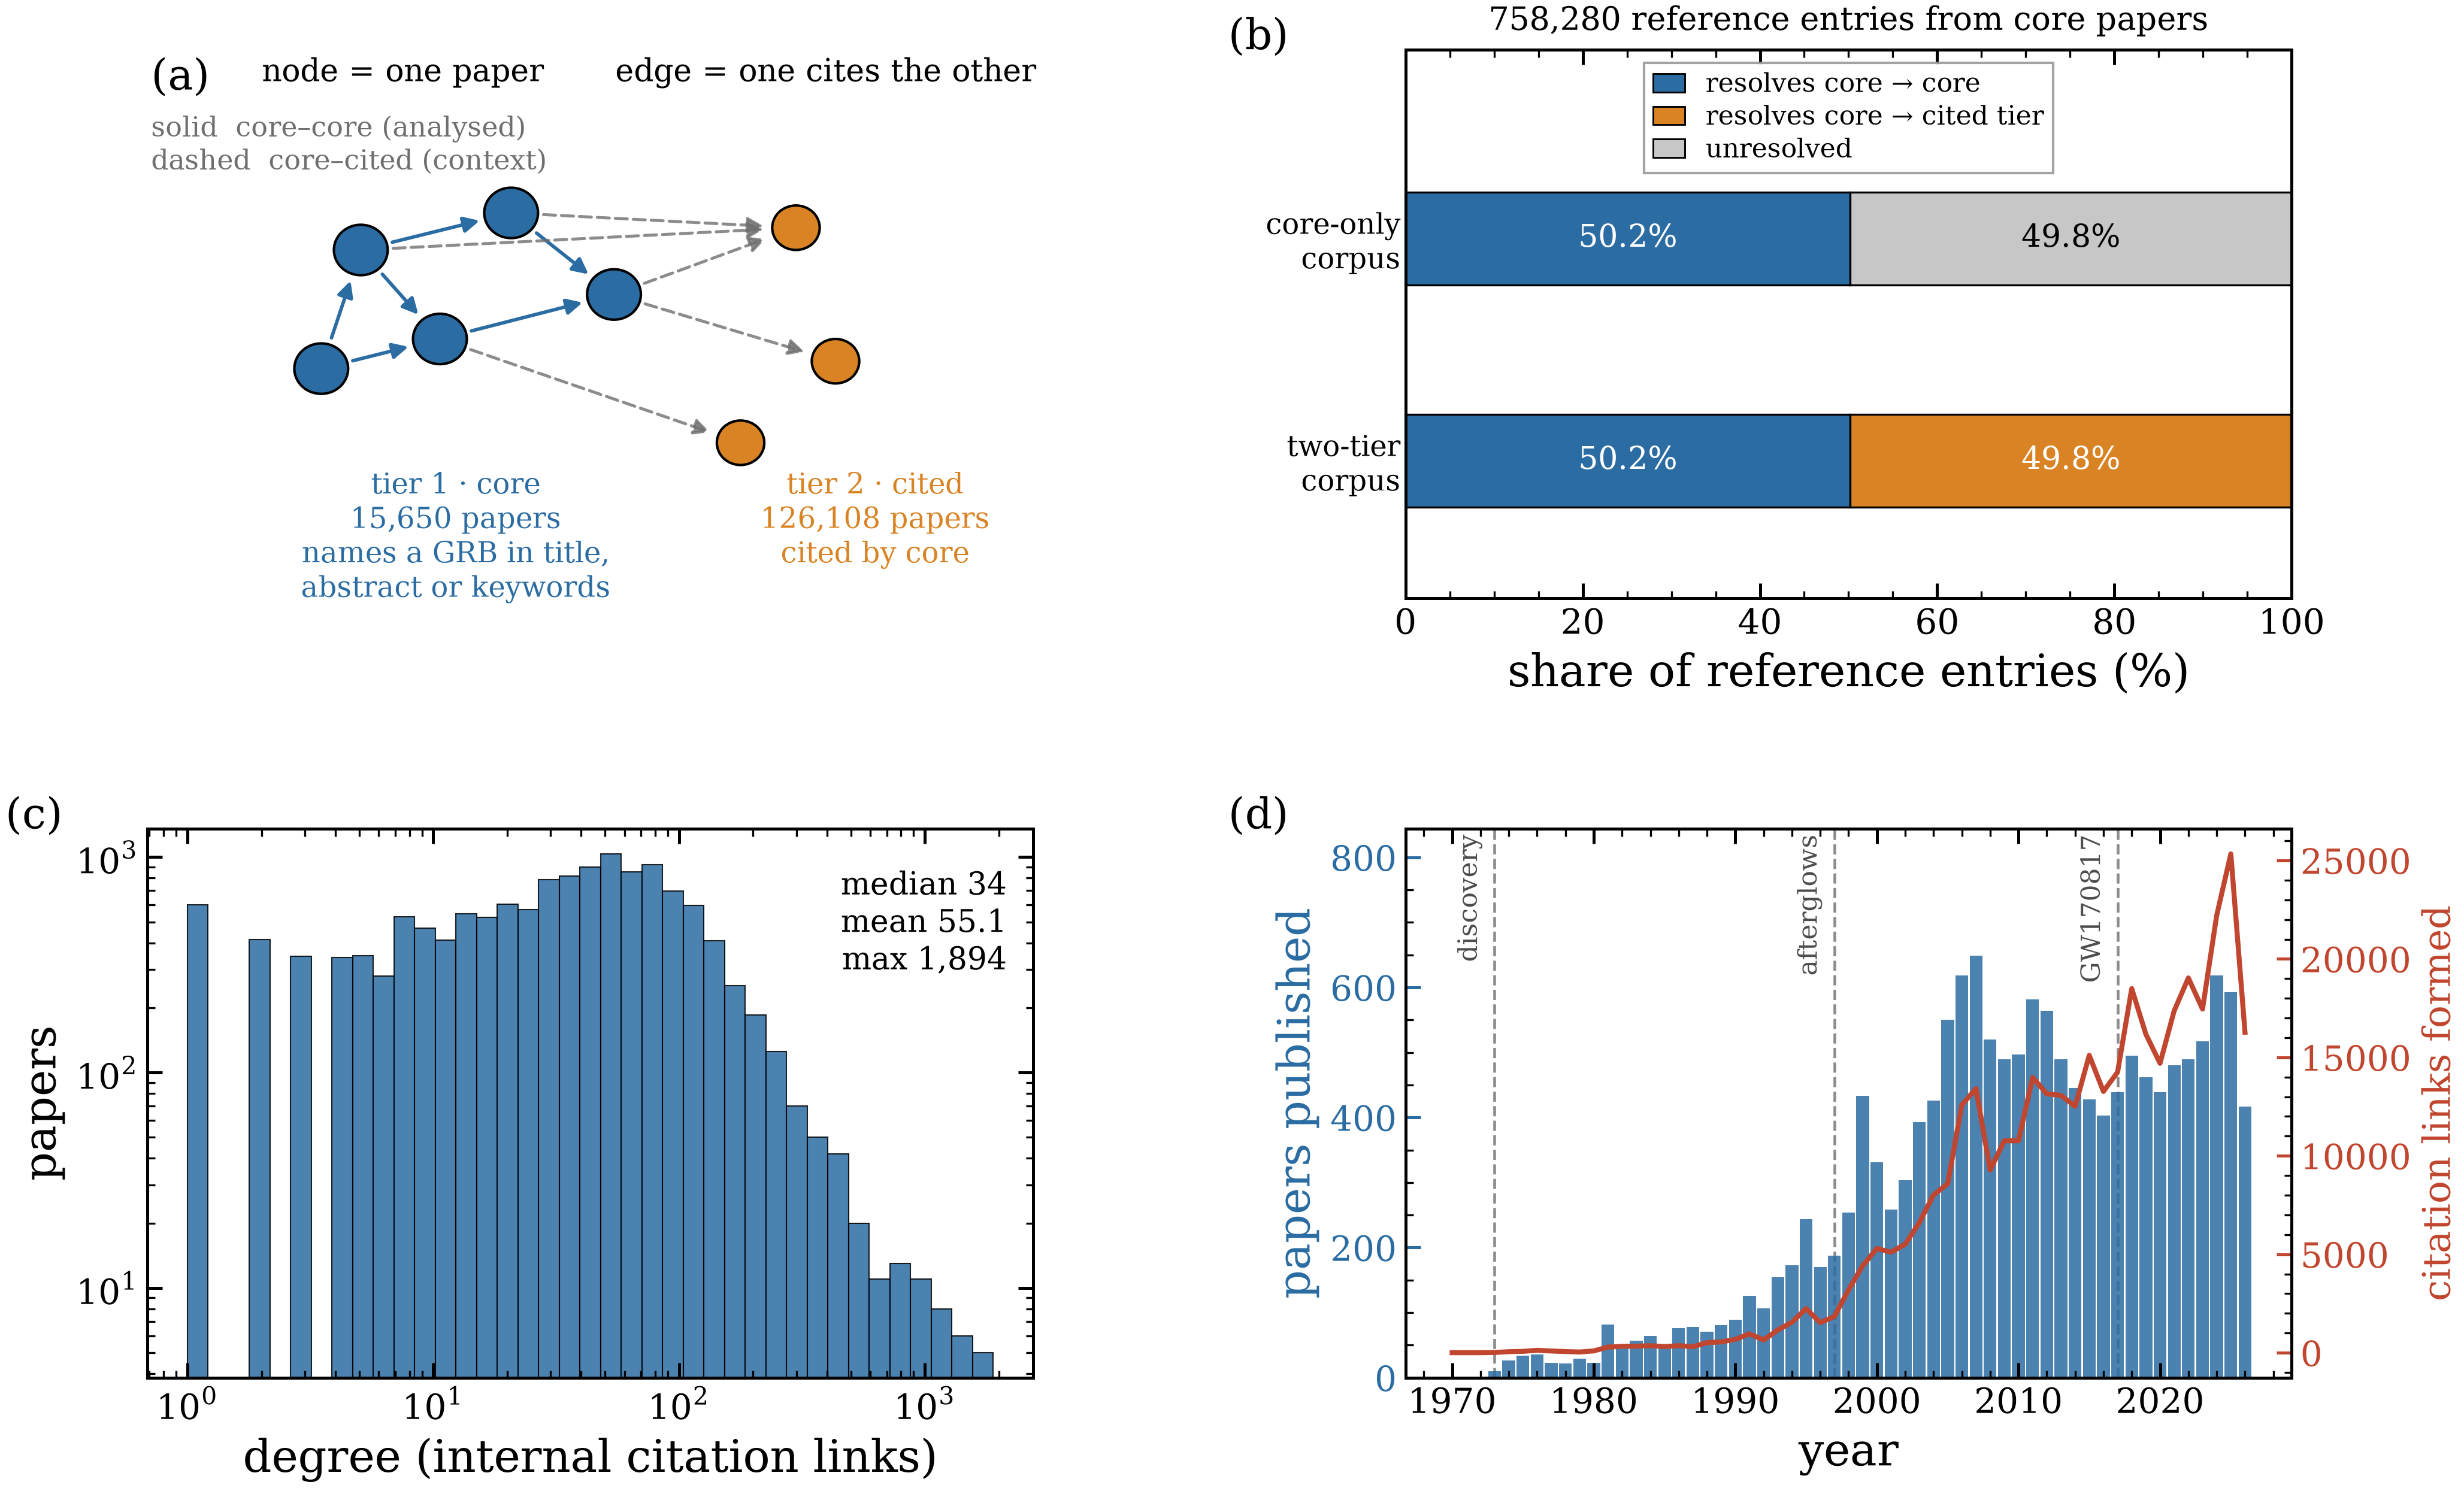

figB_citation_graph


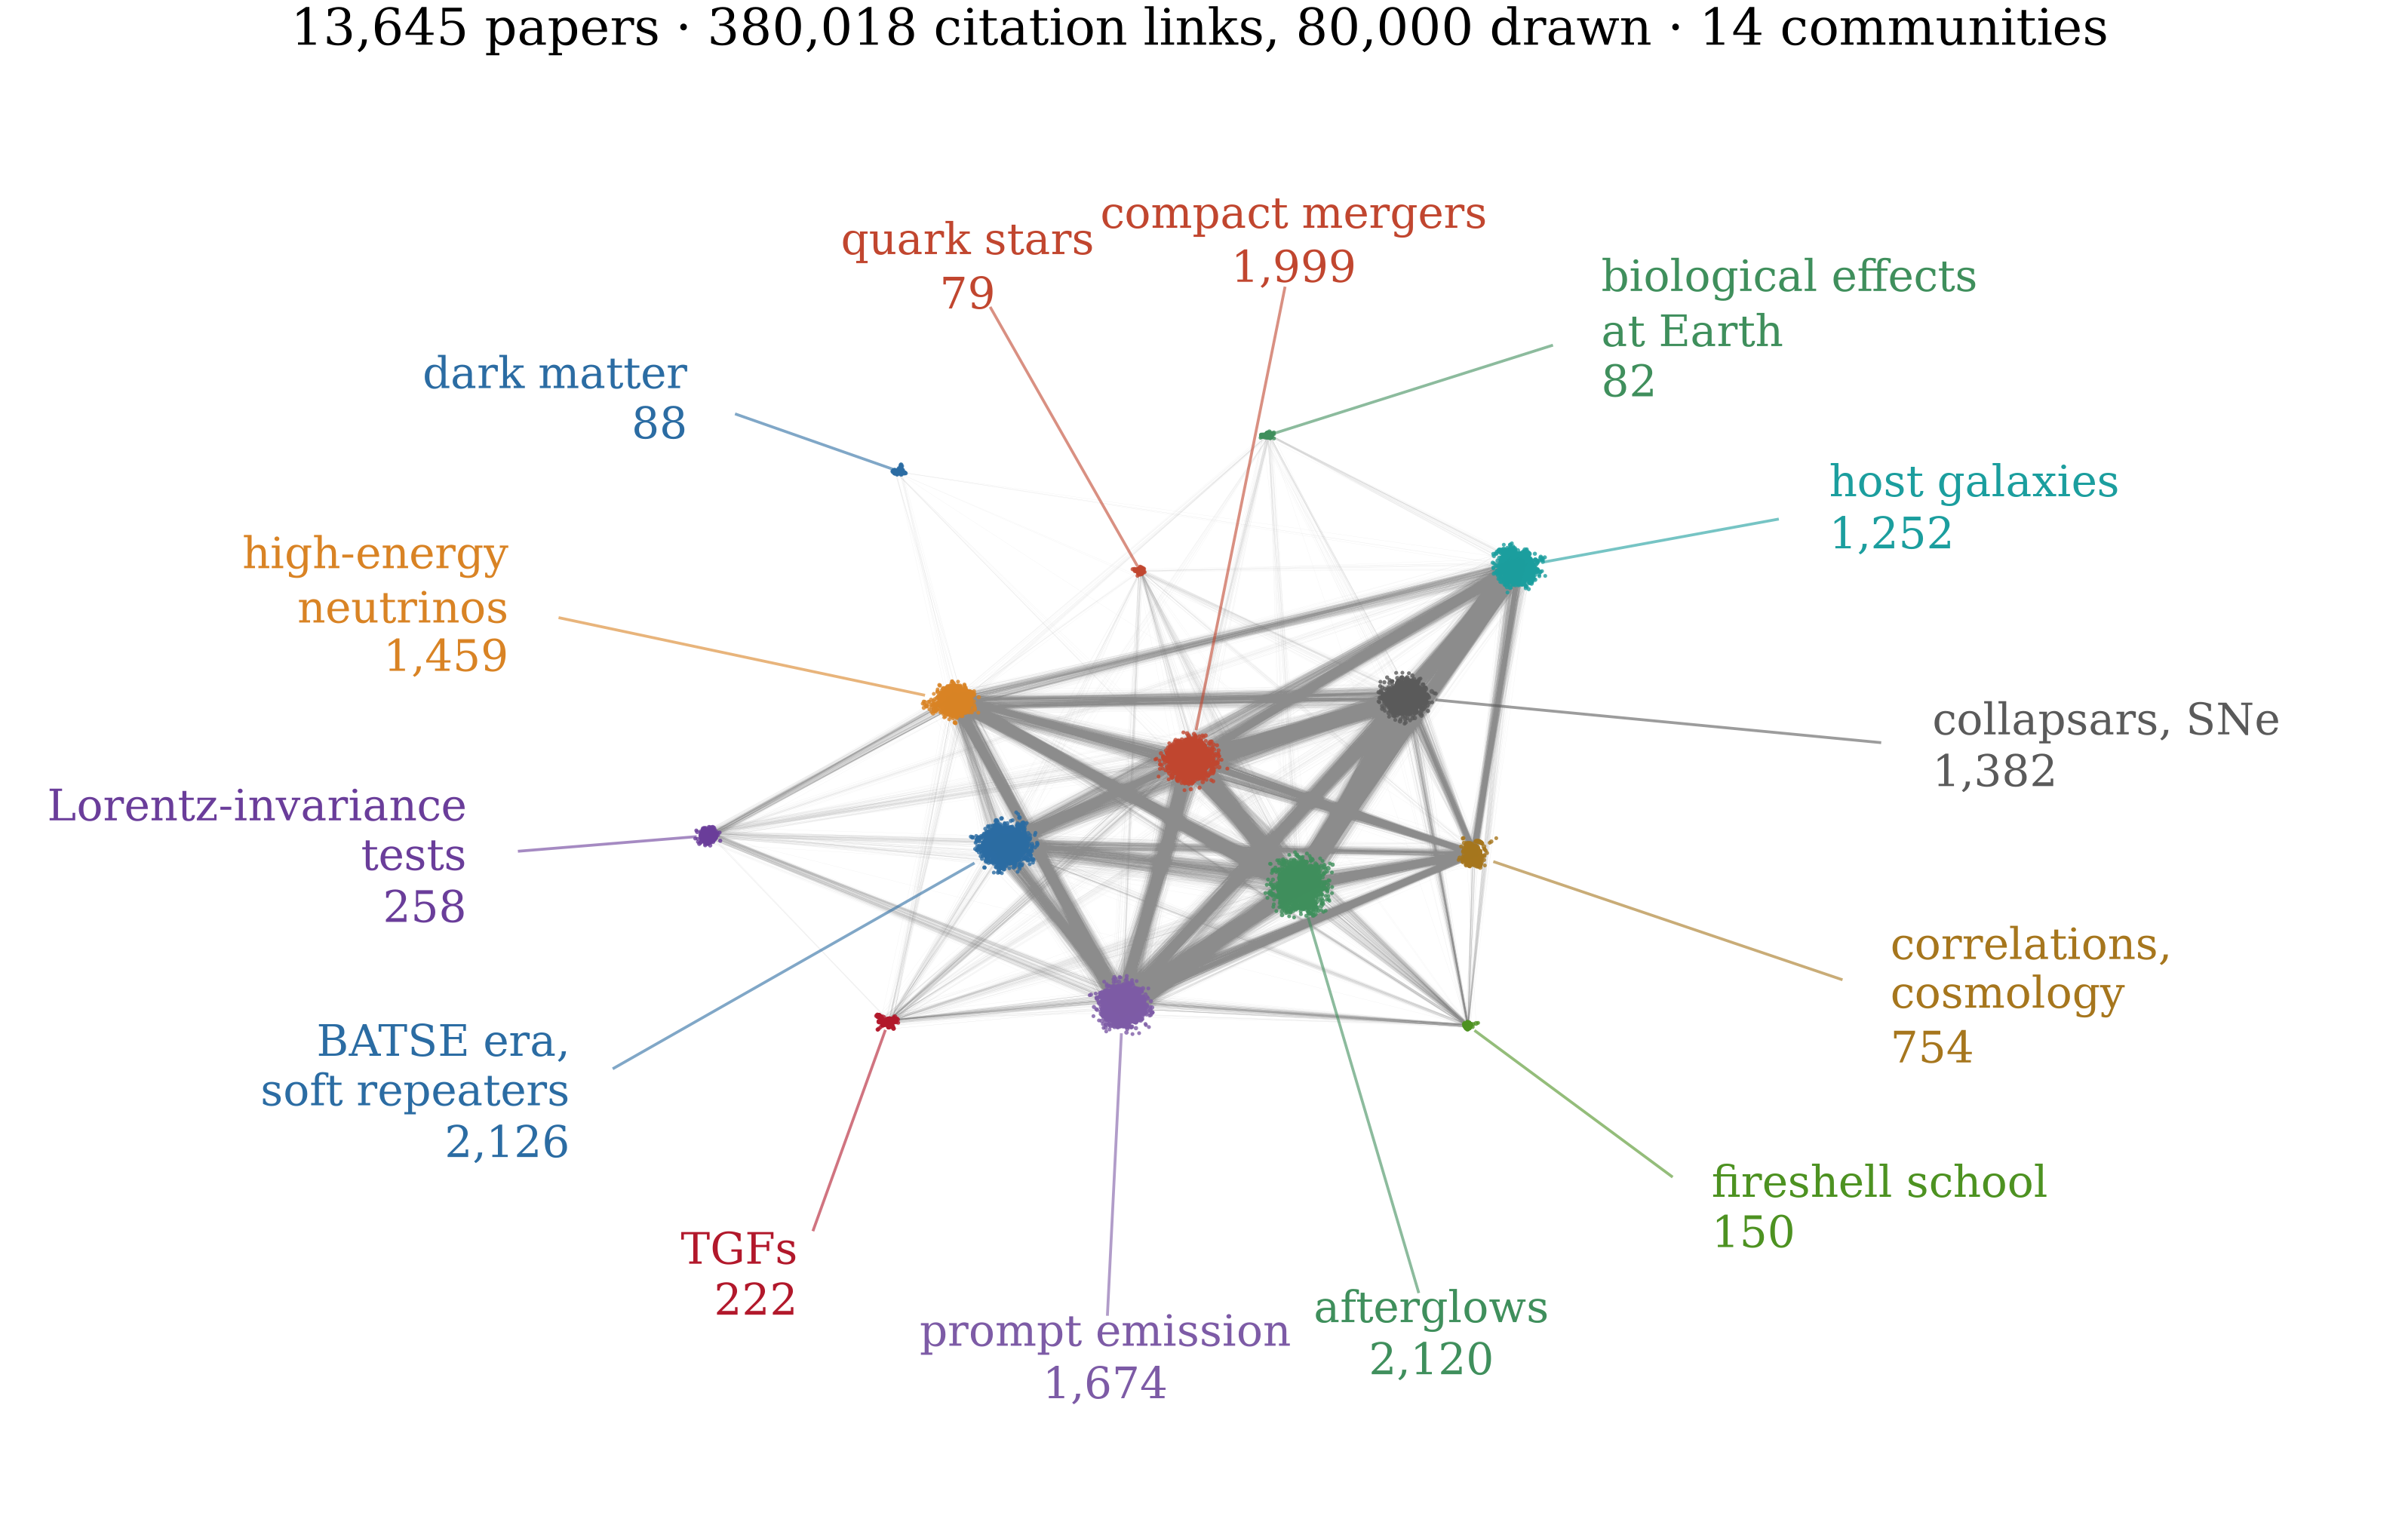

figD_role_plane


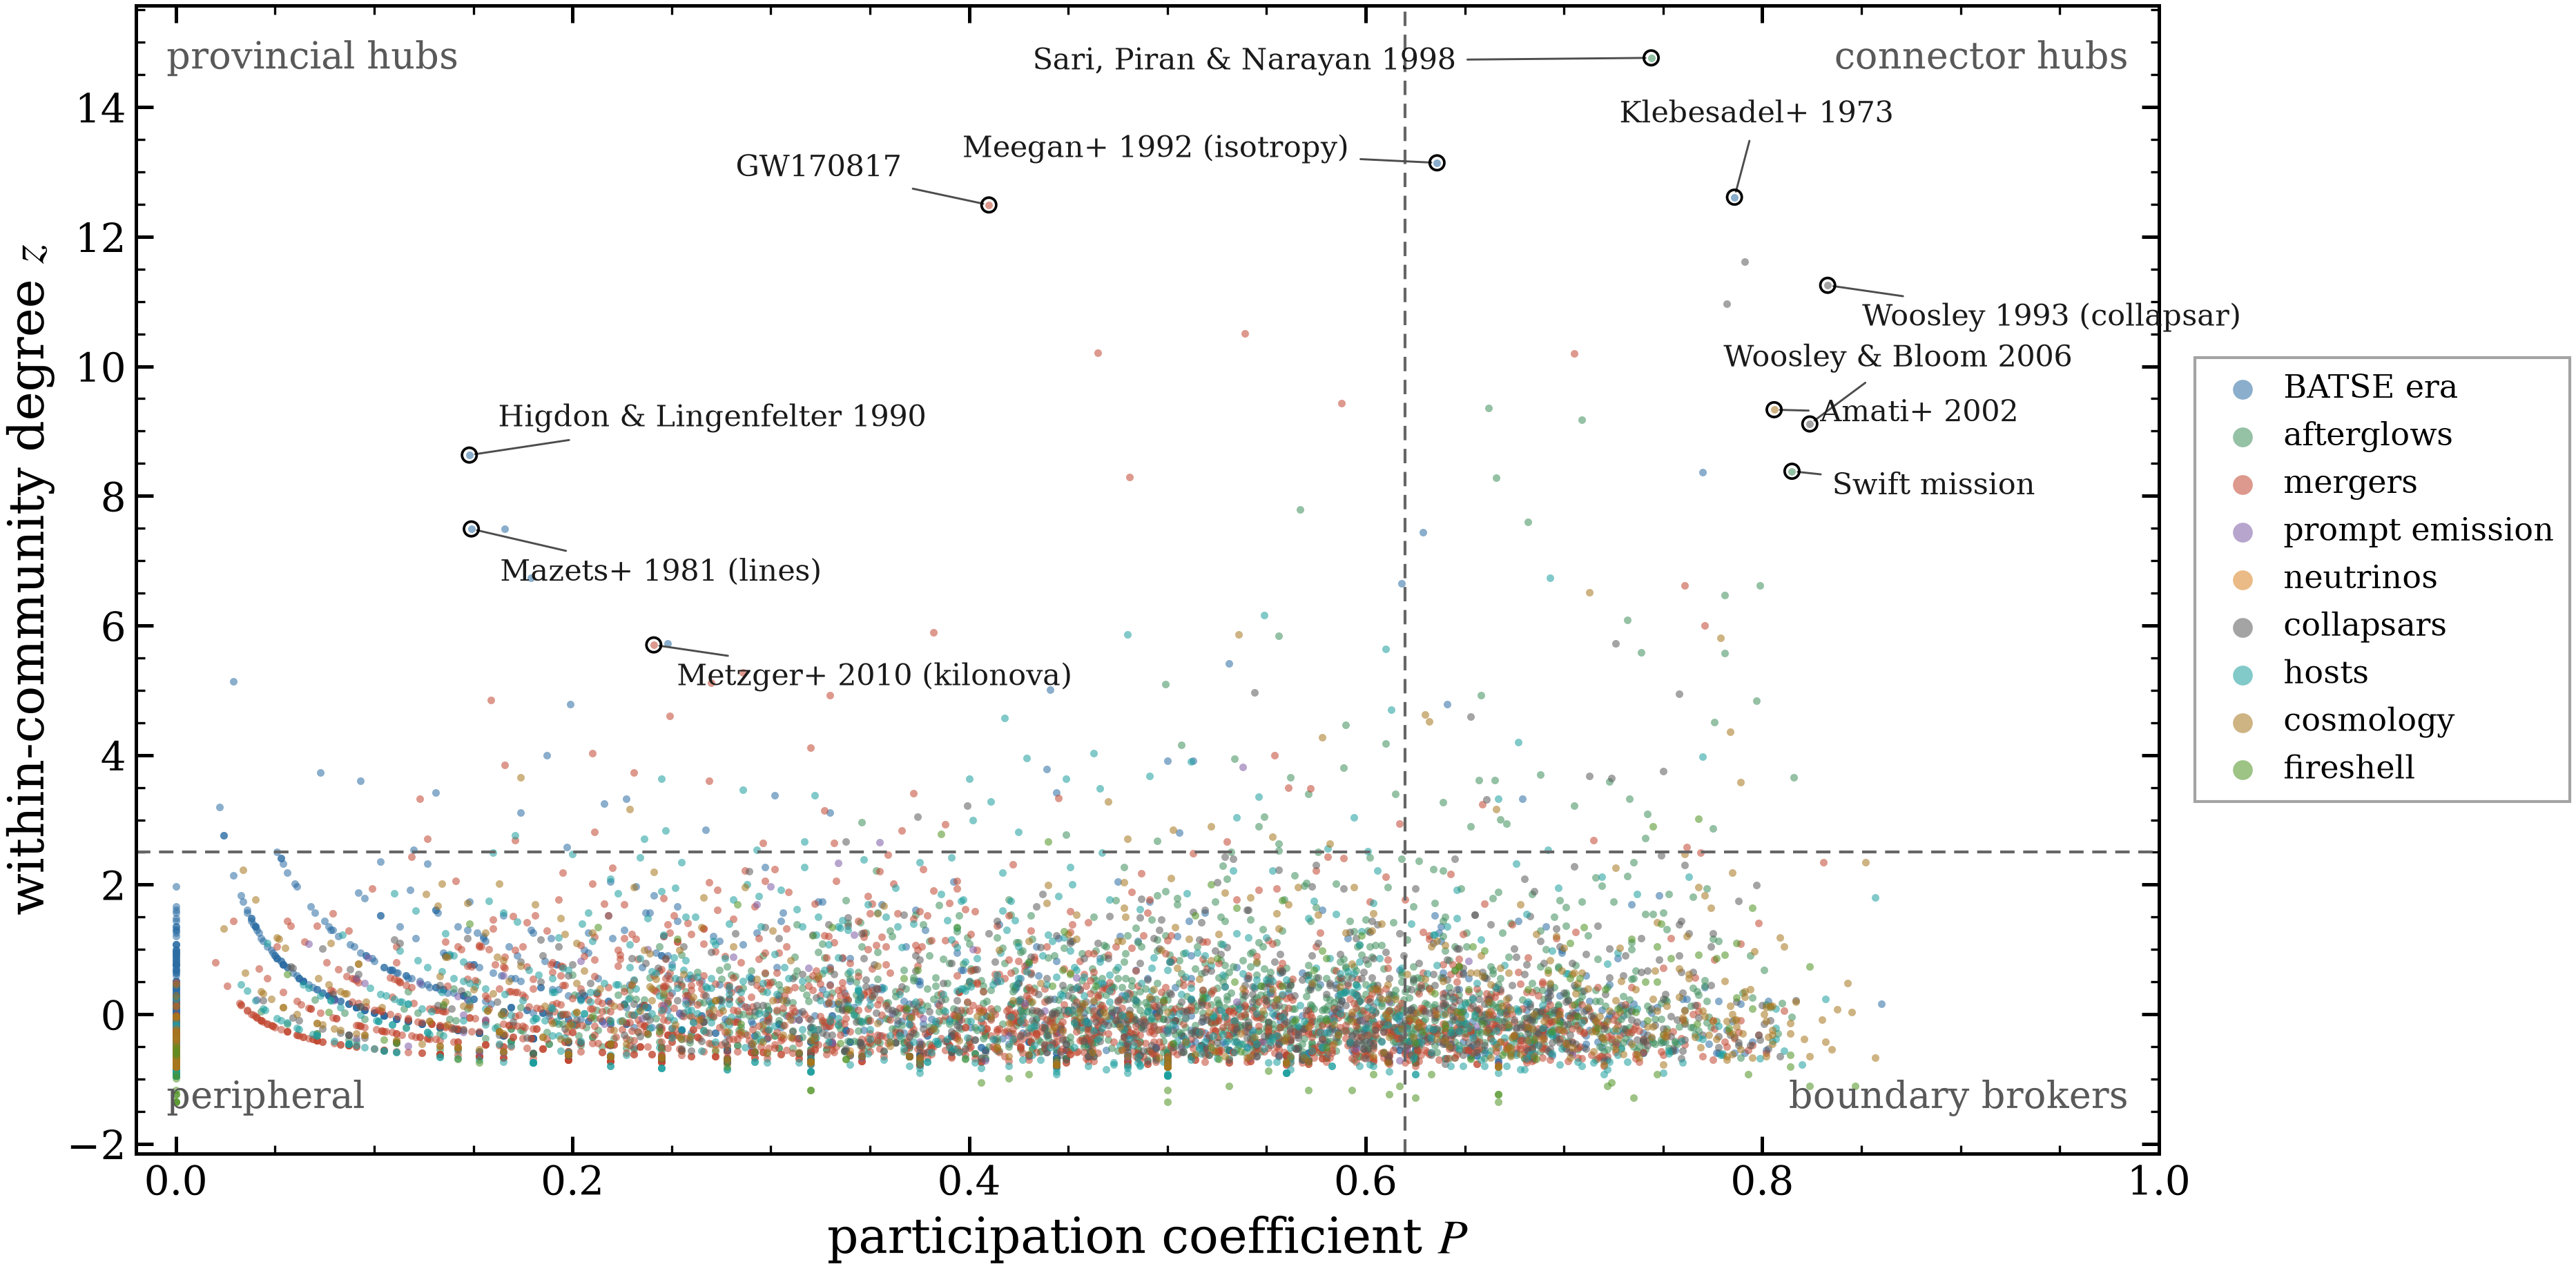

figE_alluvial


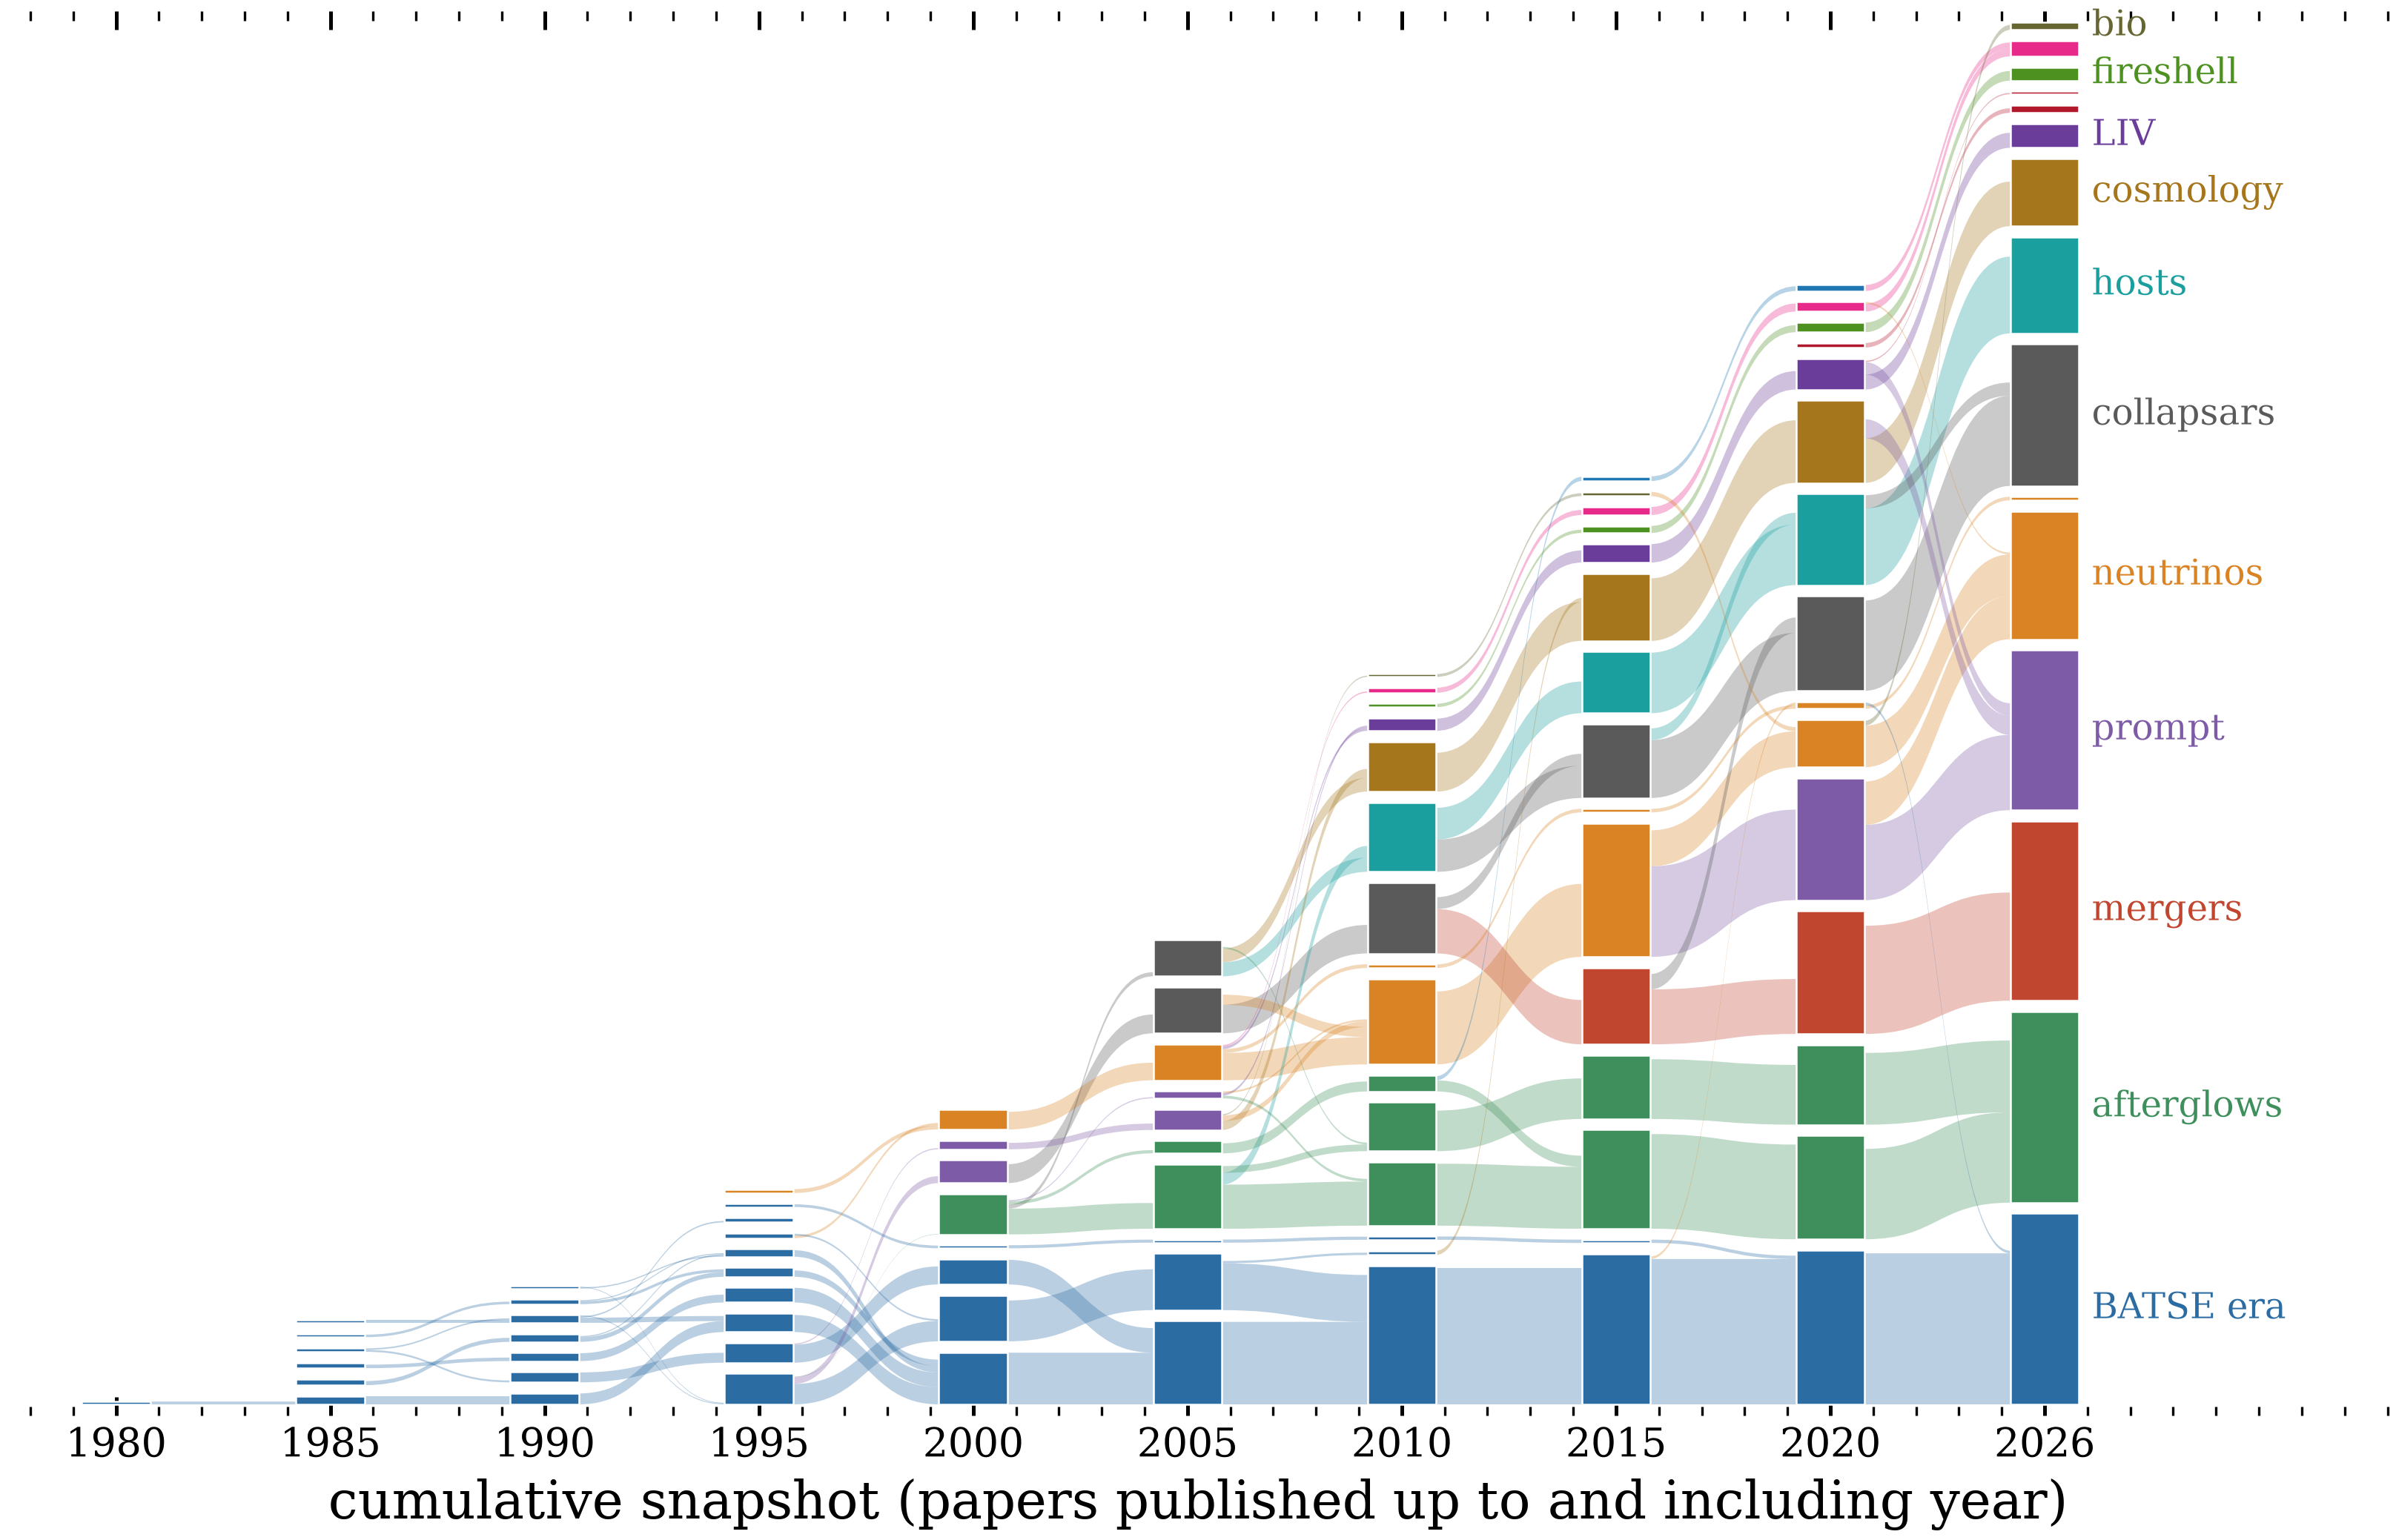

figF_infomap_nesting


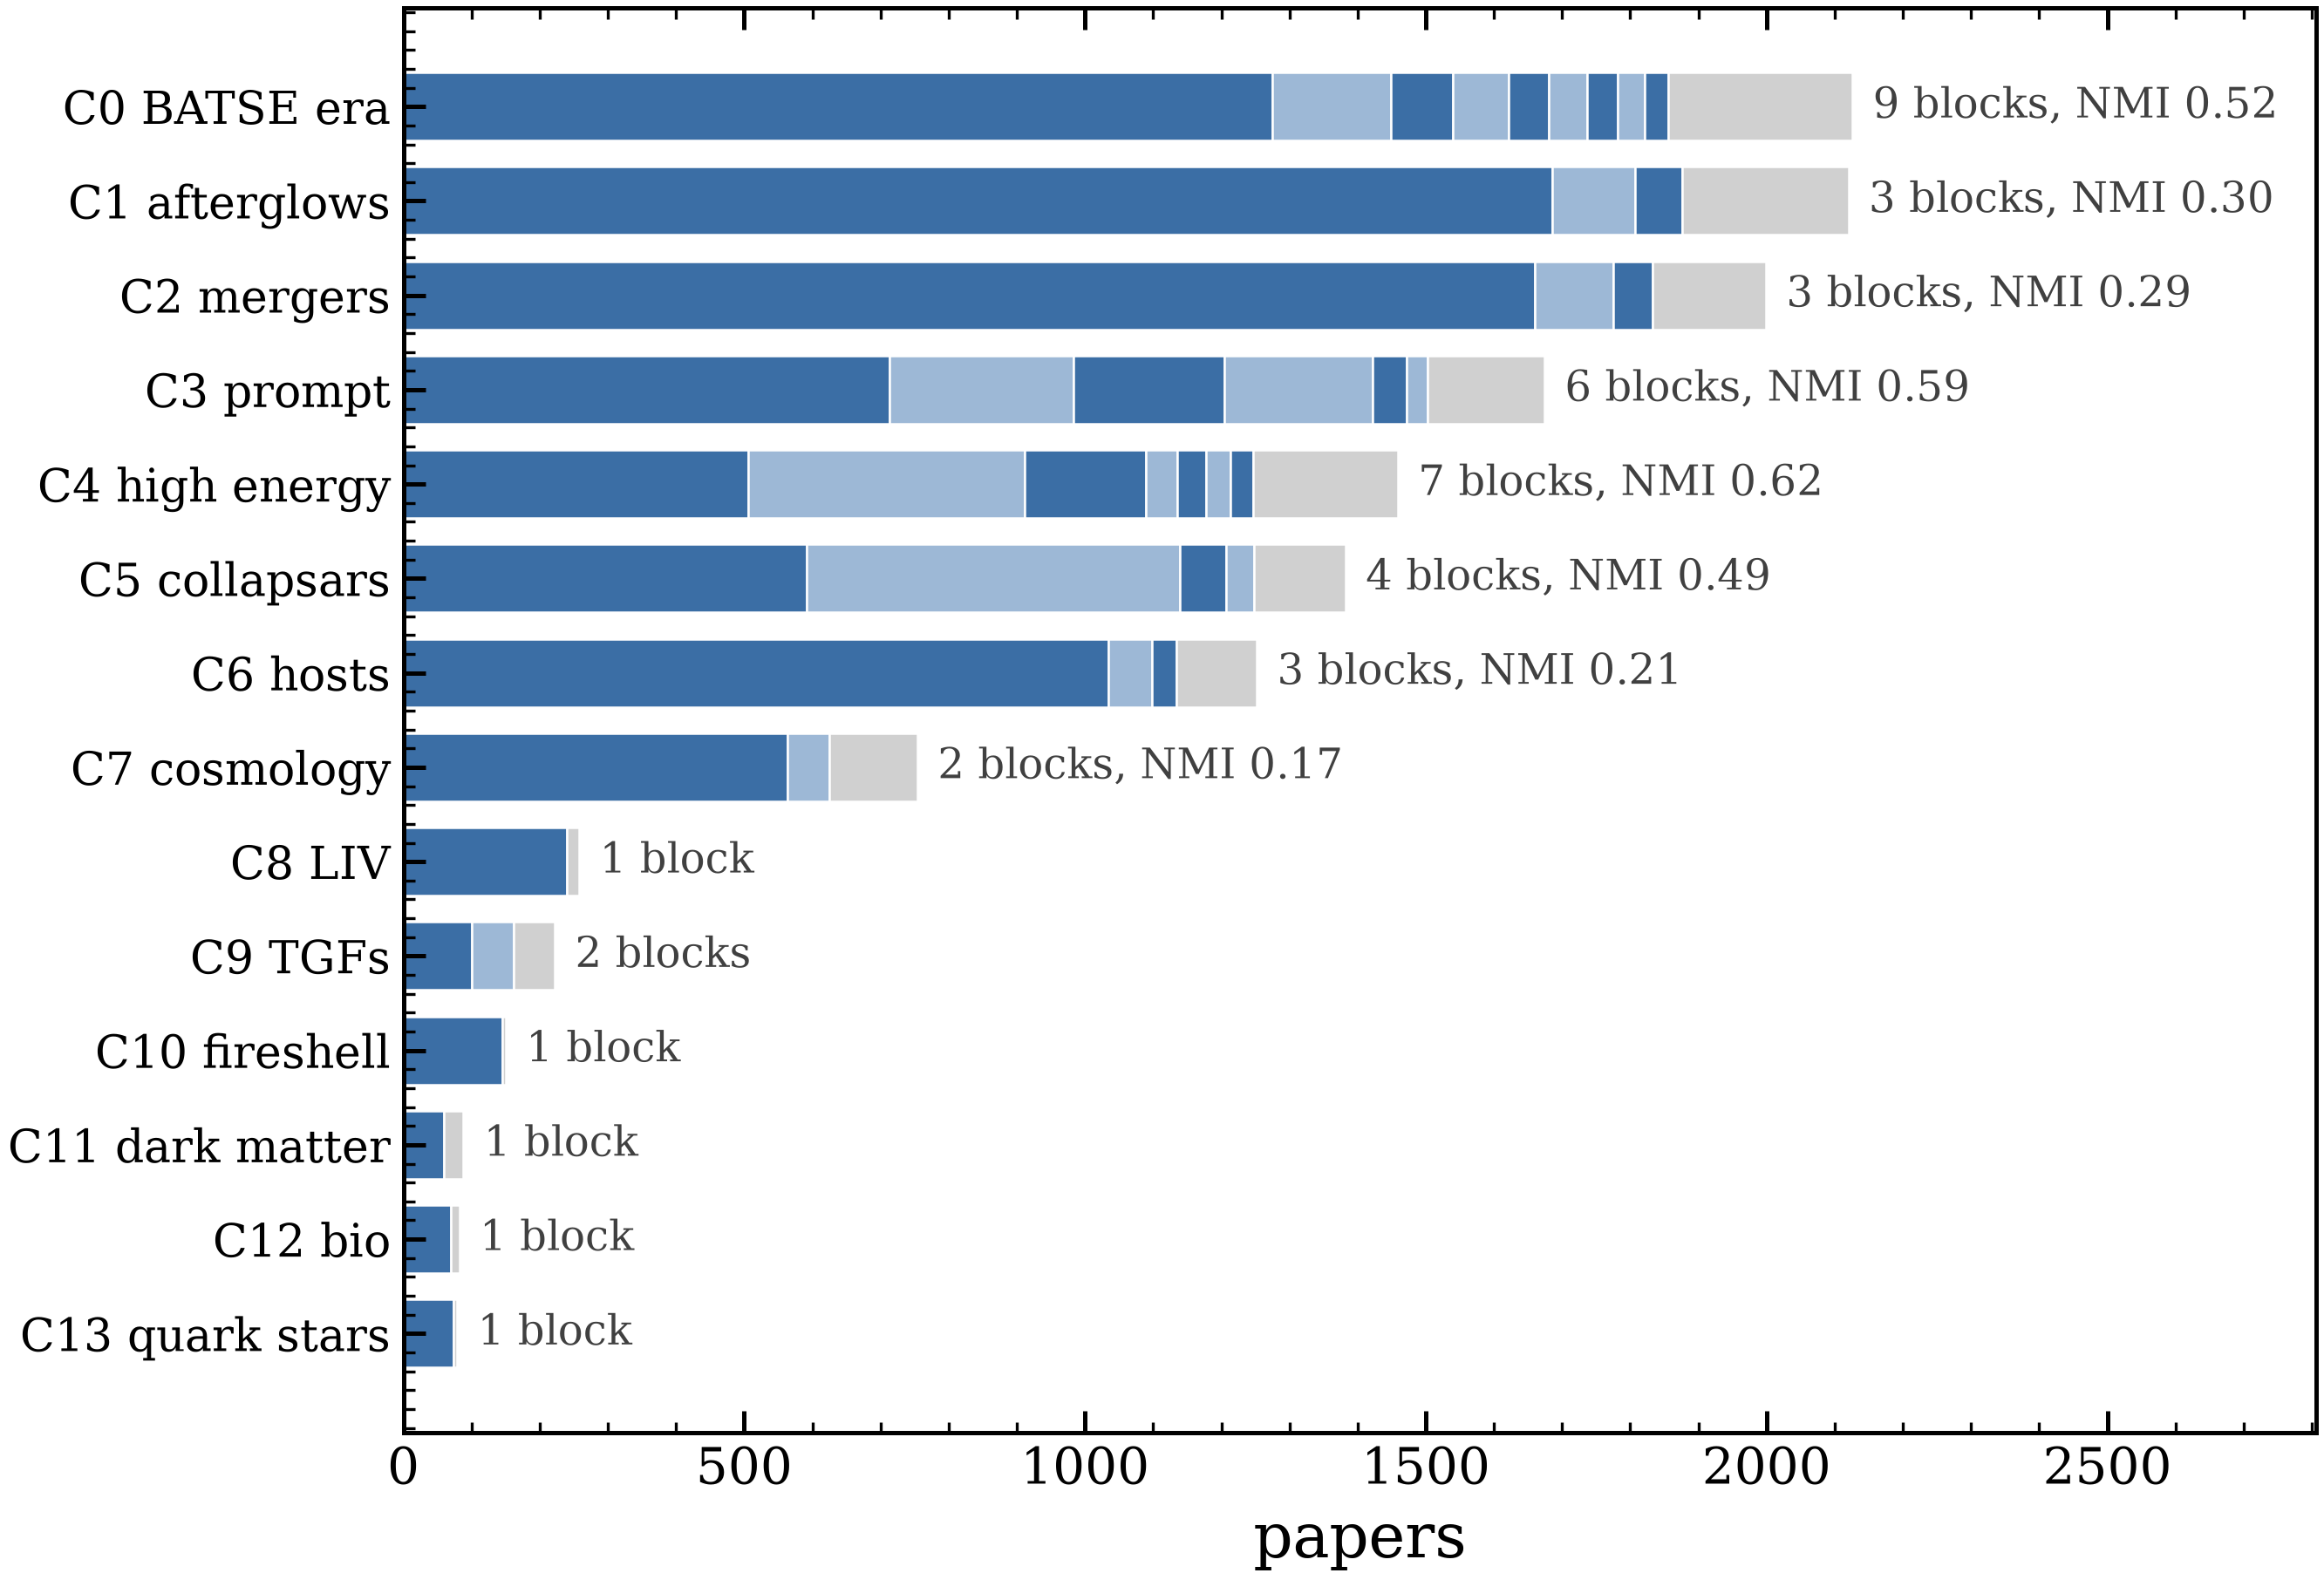

figC_pipeline


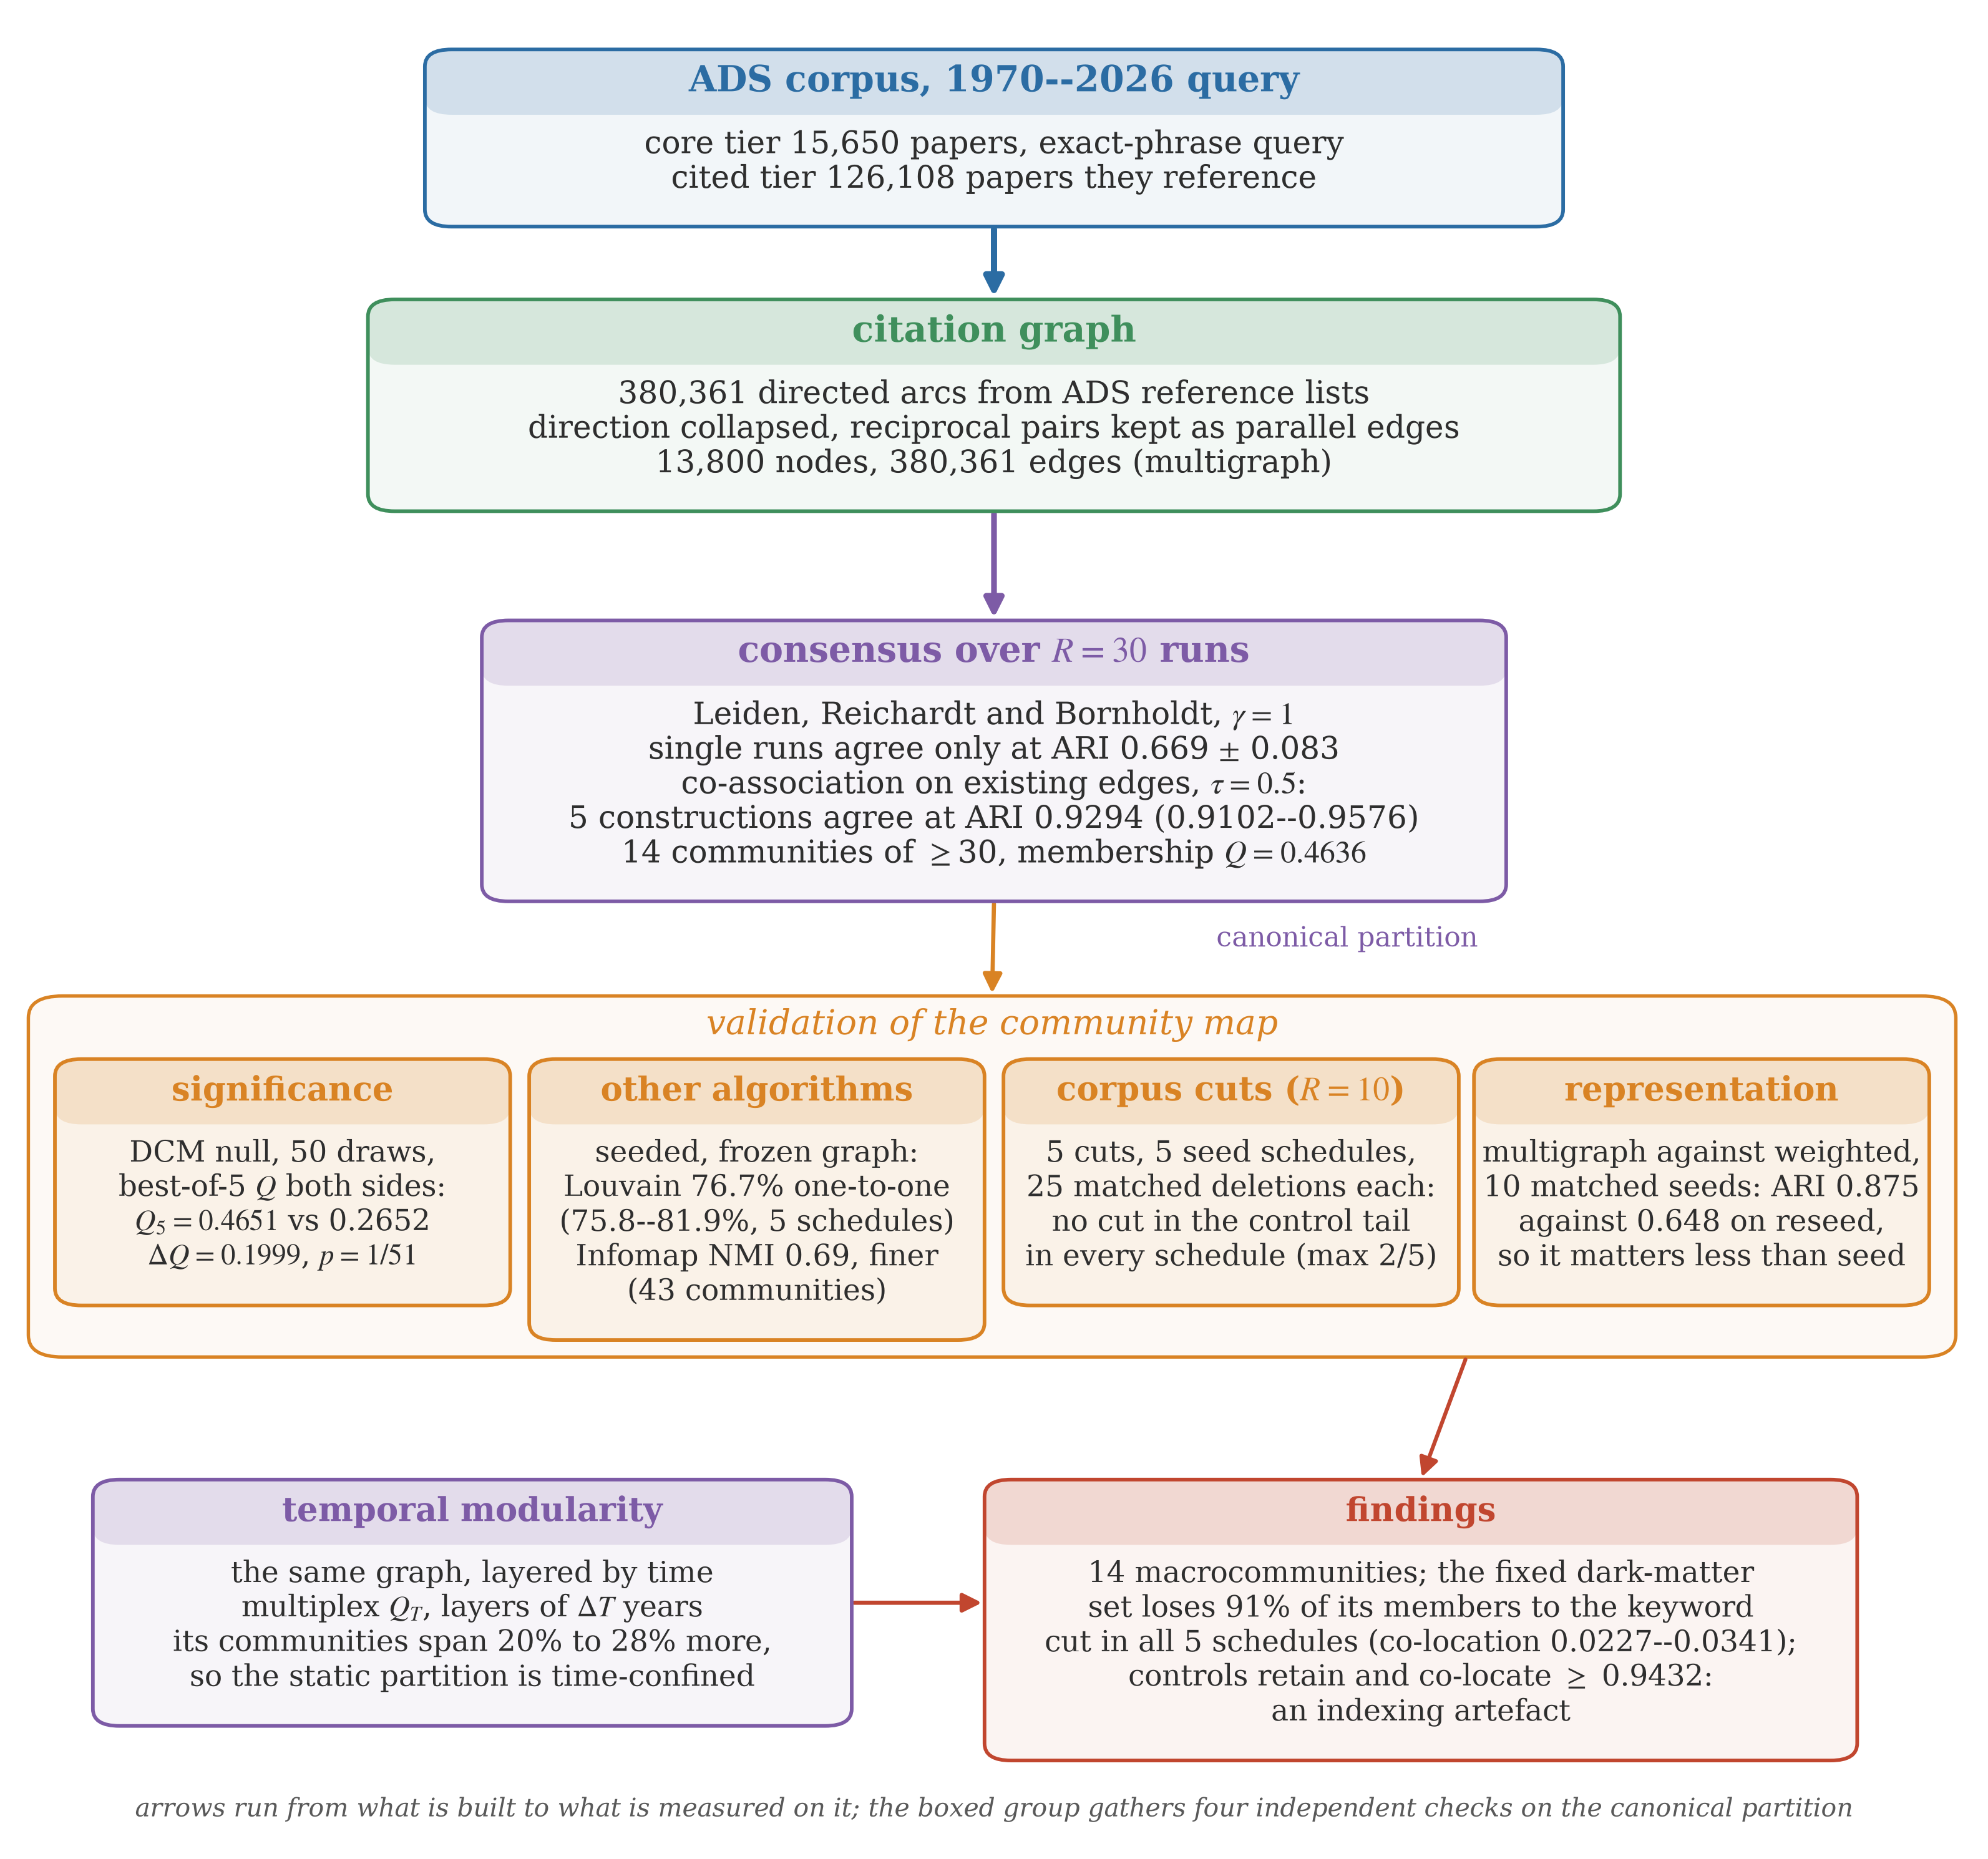

In [8]:
from IPython.display import Image, display
for f in ["figA_graph_anatomy","figB_citation_graph","figD_role_plane","figE_alluvial","figF_infomap_nesting","figC_pipeline"]:
    print(f); display(Image(filename=f"paper/figures/{f}.png", width=900))